# 5. Parallelism


In [1]:
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.types import Command
from langgraph.types import Send
from typing import TypedDict, Literal
from typing_extensions import Annotated
import operator

/var/folders/km/4c7v4jmj5ydfnj183qz7wr7w0000gn/T/ipykernel_38907/700811828.py:4: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


Define the model

In [2]:
llm = AzureChatOpenAI(model="gpt-4.1-mini")

Since we will be running items in parallel, we will need to store the output of each node in a state. Therefore we need to define an object that will store those items in memory. 

Notice though that we make use of the operator.add, this is an easier way to extend a list variable.

In [3]:
class OurCustomState(TypedDict):
    cities: list[str]
    facts: Annotated[list, operator.add]


class CityState(TypedDict):
    city: str

A node/agent that will give us advice about a city

In [4]:
def city_advice(state: CityState) -> str:
    print("Node: CityAdvice")
    response = llm.invoke(
        input=[
            HumanMessage(
                content=f"Tell me 3 interesting facts about {state['city']}. "
                "Only return the facts, no other text. Use a numbered list."
                "Start with the city name. Ex. # CityName"
            )
        ]
    )

    return {"facts": [response.content]}

A node/agent that will return random cities.

And will execute the city advice node for each one of them. 

Notice we return a Command with goto, this also means when we built or graph we do not need to make a link between the two.

In [5]:
def random_city_generator(
    state: OurCustomState,
) -> Command[Literal["city_advice", "final_node"]]:
    print("Node: Random City Generator")
    response = llm.invoke(
        input="Return 3 random city names in Finland, comma separated."
    )
    cities = response.content.split(",")
    if len(cities) > 0:
        return Command(
            update={"cities": cities},
            goto=[
                Send(node="city_advice", arg={"city": city.strip()}) for city in cities
            ],
        )
    else:
        return Command(update={"cities": []}, goto=["final_node"])

A final node purely for demonstration purposes to print the collected info

In [6]:
def final_node(state: OurCustomState):
    print("Node: Final")
    print("Cities:", state["cities"])
    print("Facts:", state["facts"])
    return {}

Setting up a langgraph graph.

Notice that there is no link between random_city_generator and city_advice. Not needed because of the goto.

In [7]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(OurCustomState)

builder.add_node("random_city_generator", random_city_generator)
builder.add_node("city_advice", city_advice)
builder.add_node("final_node", final_node)

builder.add_edge(START, "random_city_generator")
builder.add_edge("city_advice", "final_node")
builder.add_edge("final_node", END)
graph = builder.compile()

Printing out the workflow diagram

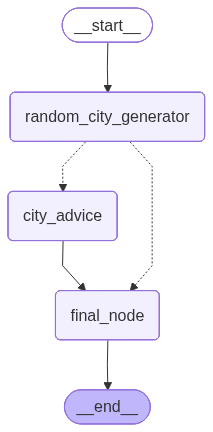

In [8]:
from IPython.display import Image

Image(graph.get_graph(xray=1).draw_mermaid_png())

Executing the workflow

In [9]:
state = graph.invoke(input={})

Node: Random City Generator
Node: CityAdviceNode: CityAdvice

Node: CityAdvice
Node: Final
Cities: ['Helsinki', ' Turku', ' Oulu']
Facts: ['# Helsinki  \n1. Helsinki is known as the "Daughter of the Baltic" because of its coastal location on the Gulf of Finland.  \n2. The city hosts the world\'s northernmost metro system, which opened in 1982.  \n3. Helsinki was once part of Sweden and then the Russian Empire before becoming the capital of independent Finland in 1917.', "# Turku  \n1. Turku is the oldest city in Finland, founded in the late 13th century, and served as the country's capital until 1812.  \n2. The Turku Castle, dating back to the late 13th century, is one of the largest surviving medieval buildings in Finland and now operates as a museum.  \n3. Turku hosts the annual Medieval Market, one of the largest historical events in the Nordic countries, attracting thousands of visitors with reenactments, crafts, and performances.", '# Oulu  \n1. Oulu is known as the "Silicon Valle

Printing out the fields in the earlier defined output

In [10]:
for fact in state["facts"]:
    print(fact)

# Helsinki  
1. Helsinki is known as the "Daughter of the Baltic" because of its coastal location on the Gulf of Finland.  
2. The city hosts the world's northernmost metro system, which opened in 1982.  
3. Helsinki was once part of Sweden and then the Russian Empire before becoming the capital of independent Finland in 1917.
# Turku  
1. Turku is the oldest city in Finland, founded in the late 13th century, and served as the country's capital until 1812.  
2. The Turku Castle, dating back to the late 13th century, is one of the largest surviving medieval buildings in Finland and now operates as a museum.  
3. Turku hosts the annual Medieval Market, one of the largest historical events in the Nordic countries, attracting thousands of visitors with reenactments, crafts, and performances.
# Oulu  
1. Oulu is known as the "Silicon Valley of the North" due to its strong technology sector and numerous tech startups.  
2. It hosts the annual Air Guitar World Championships, attracting partic